# Preparación de los datos 

## Selecciona el conjunto de datos a utilizar.

Las estaciones que se decidieron utilizar son:

* Noroeste 2 - García
* Noroeste 3 - García
* Suroeste - Santa Catarina
* Este - Pesquería
* Sureste 3 - Cadereyta

In [2]:
import pandas as pd

In [3]:
NO2 = pd.read_csv('../data_estaciones/BD_NO2.csv') # García
NO3 = pd.read_csv('../data_estaciones/BD_NO3.csv') # García
SO = pd.read_csv('../data_estaciones/BD_SO.csv') # Santa Catarina
NE3 = pd.read_csv('../data_estaciones/BD_NE3.csv') # Pesquería
SE3 = pd.read_csv('../data_estaciones/BD_SE3.csv') # Cadereyta

Se excluye la variable Nox porque es una combinación lineal de las otras dos.

In [ ]:
# Excluir variable NOX

NO2 = NO2.drop(columns=['NOX'])
NO3 = NO3.drop(columns=['NOX'])
SO = SO.drop(columns=['NOX'])
NE3 = NE3.drop(columns=['NOX'])
SE3 = SE3.drop(columns=['NOX'])

Las columnas objetivo serán las variables de contaminantes, estas son: PM10, PM2.5, 03, SO2, NO2, CO, NO

## Limpieza de datos

No deberían existir horas duplicadas, por lo que la cantidad de horas diferentes debe coincidir con la cantidad total de datos.

In [10]:
estaciones = [NO2, NO3, SO, NE3, SE3]

for i, estacion in enumerate(estaciones):
    print('Estacion', i)
    if estacion['date'].nunique() != len(estacion):
        print('La estacion', i, 'tiene fechas duplicadas')
    else:
        print('La estacion', i, 'no tiene fechas duplicadas')

Estacion 0
La estacion 0 no tiene fechas duplicadas
Estacion 1
La estacion 1 no tiene fechas duplicadas
Estacion 2
La estacion 2 no tiene fechas duplicadas
Estacion 3
La estacion 3 no tiene fechas duplicadas
Estacion 4
La estacion 4 no tiene fechas duplicadas


No parece haber datos duplicados.

In [11]:
columnas_numericas = list(NO2.columns)
columnas_numericas = [col for col in columnas_numericas if col != 'date' and col != 'anio']

In [13]:
import matplotlib.pyplot as plt

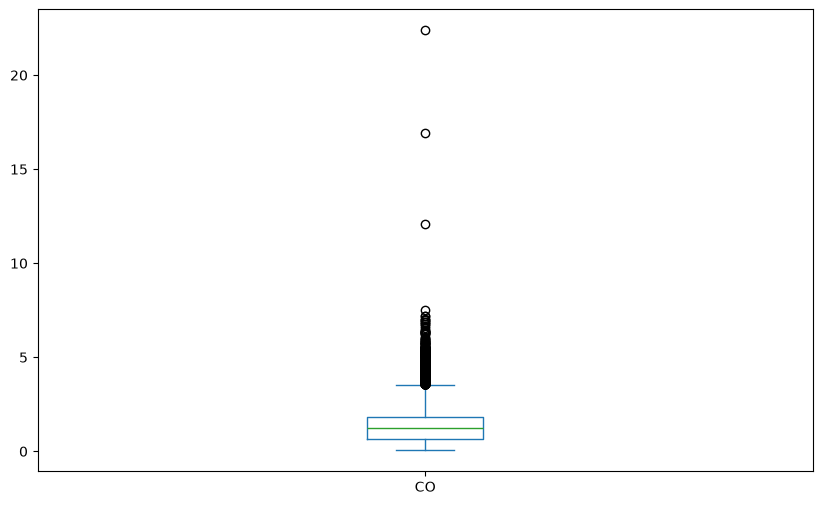

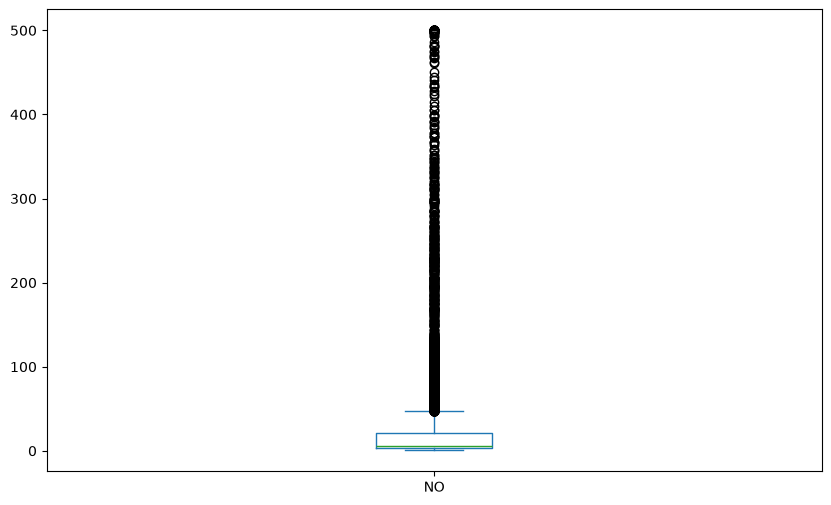

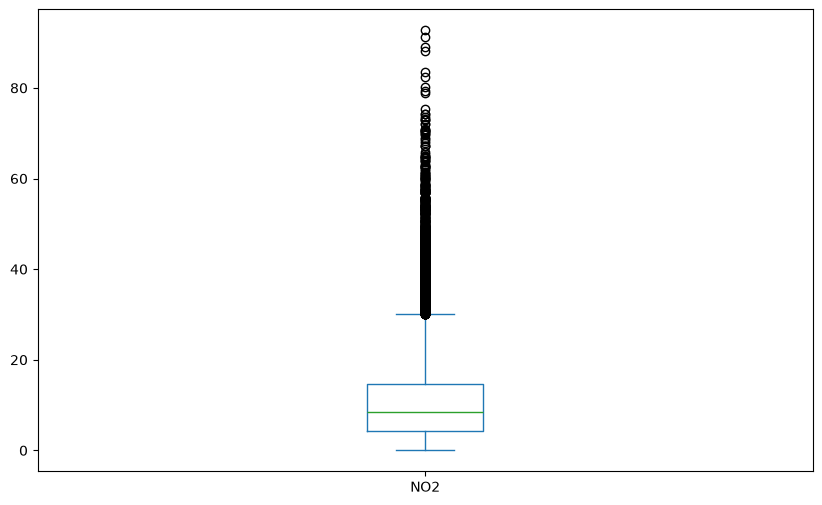

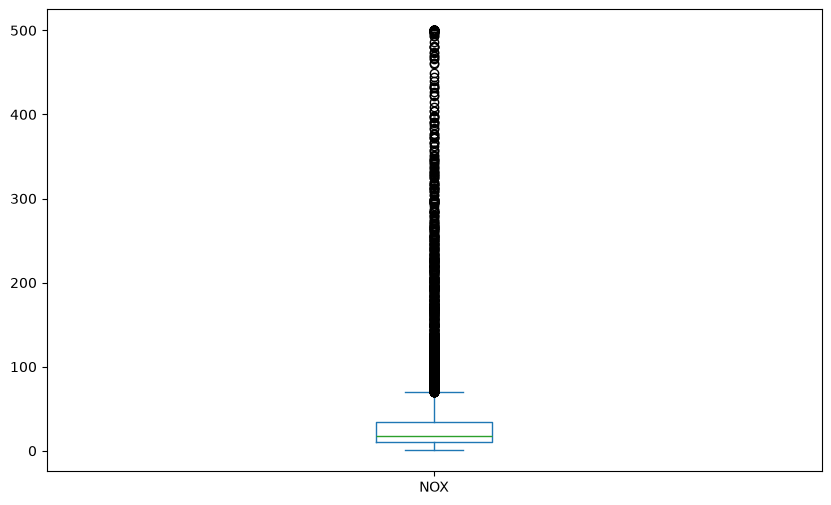

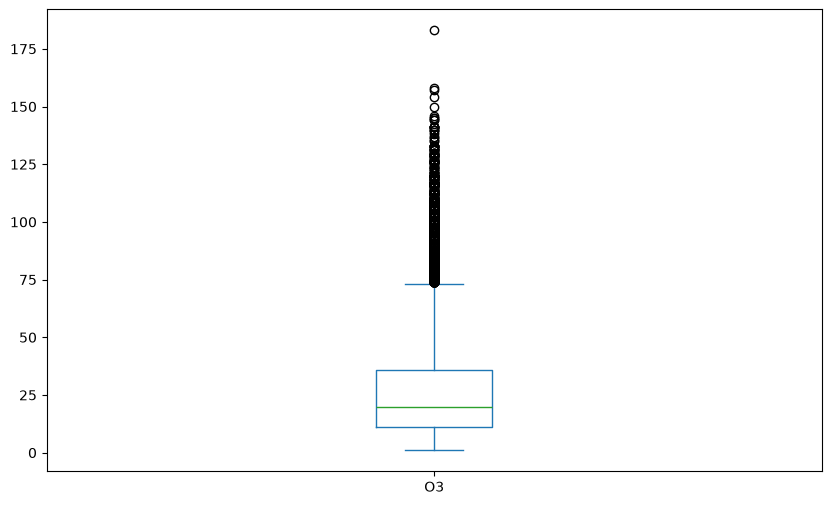

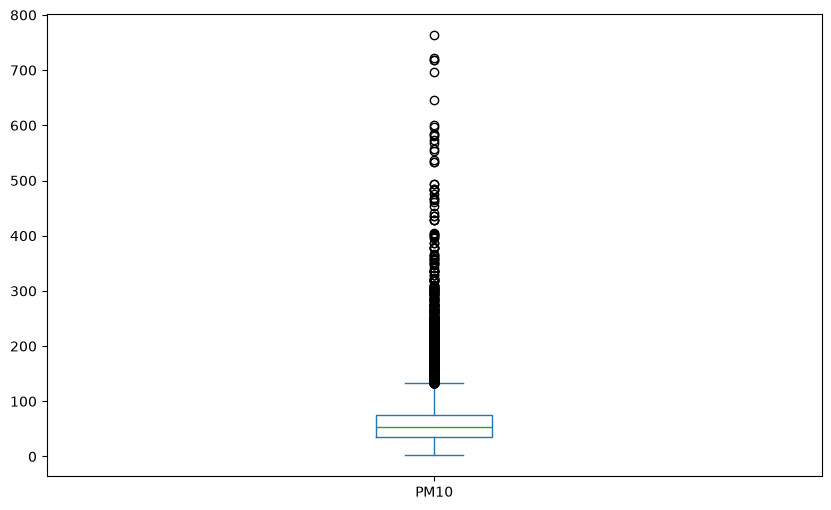

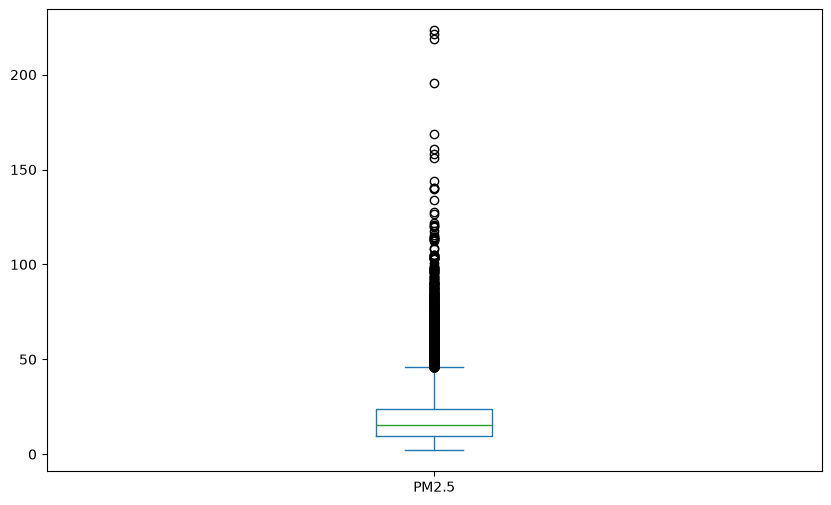

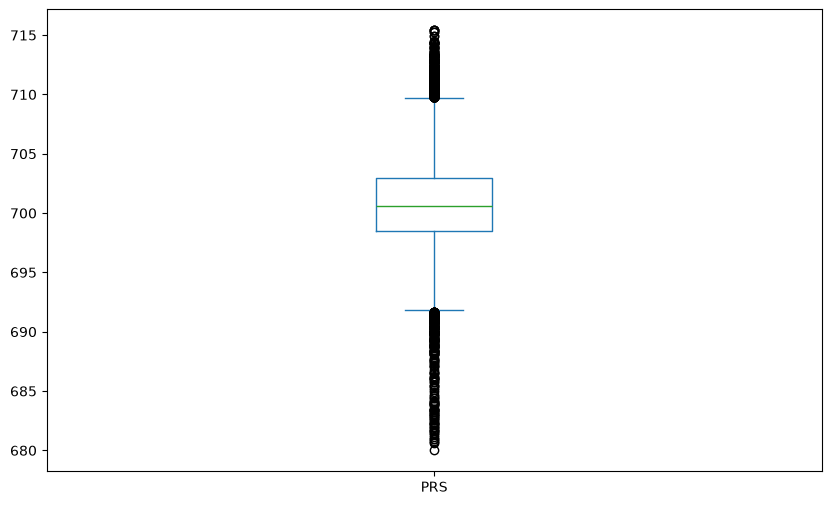

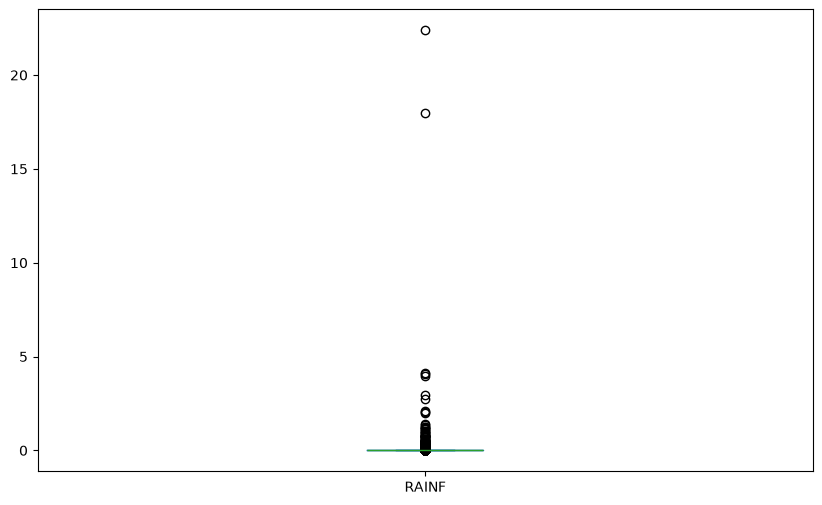

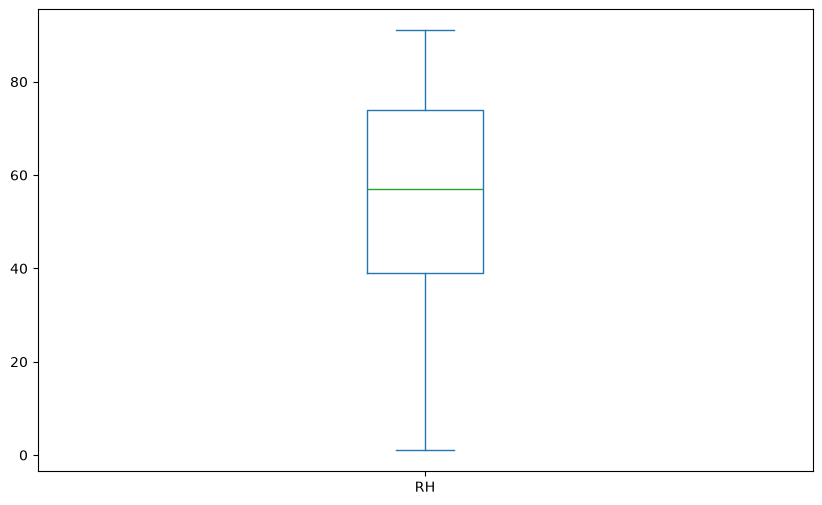

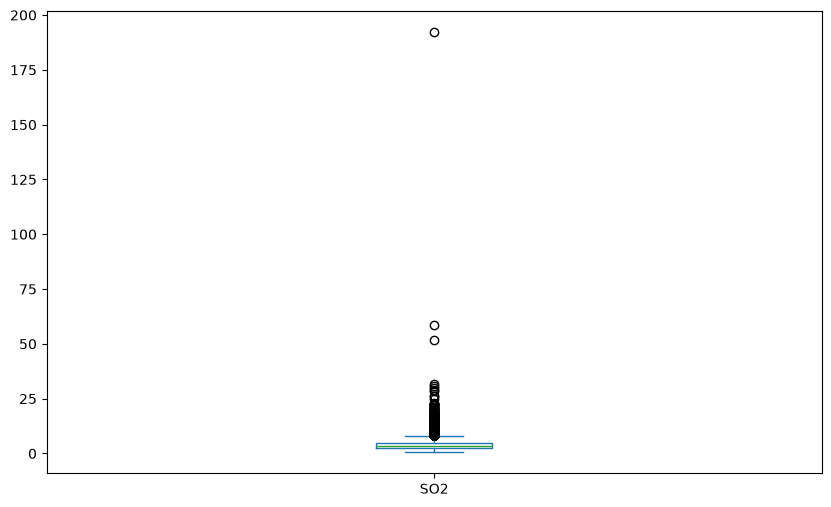

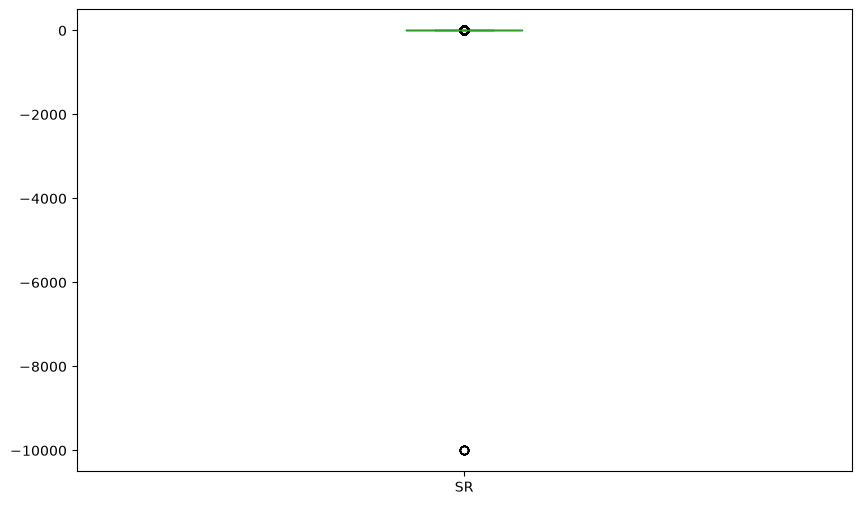

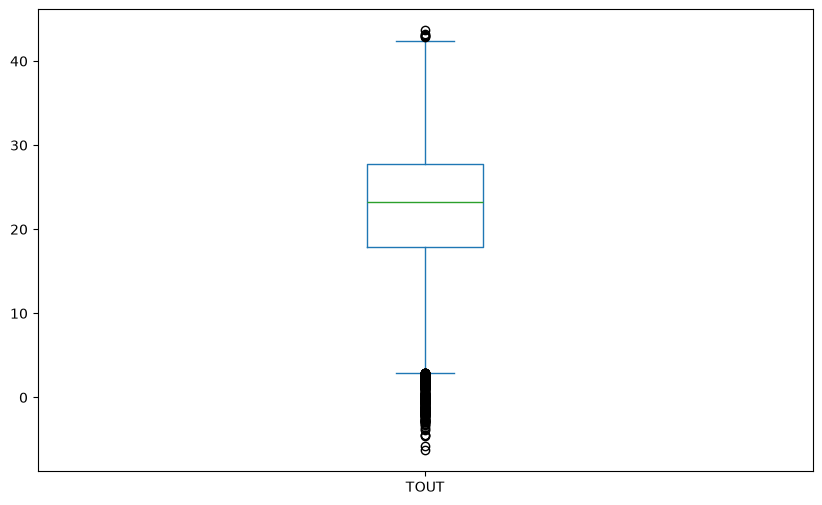

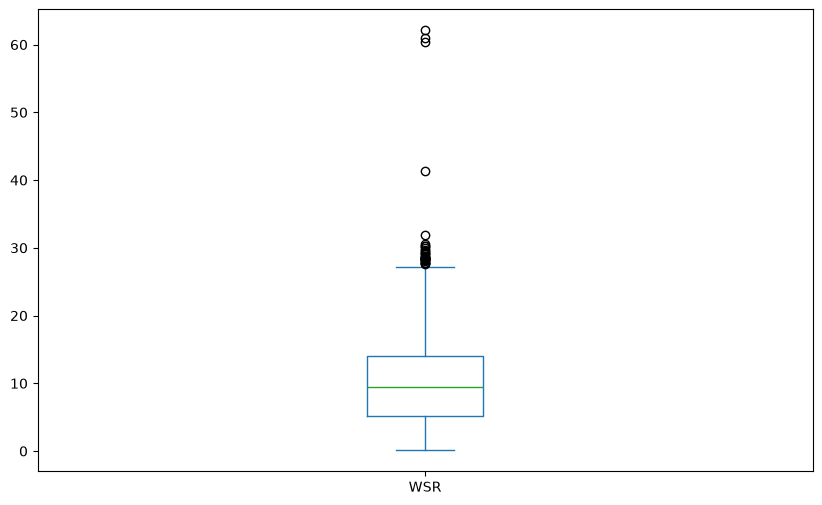

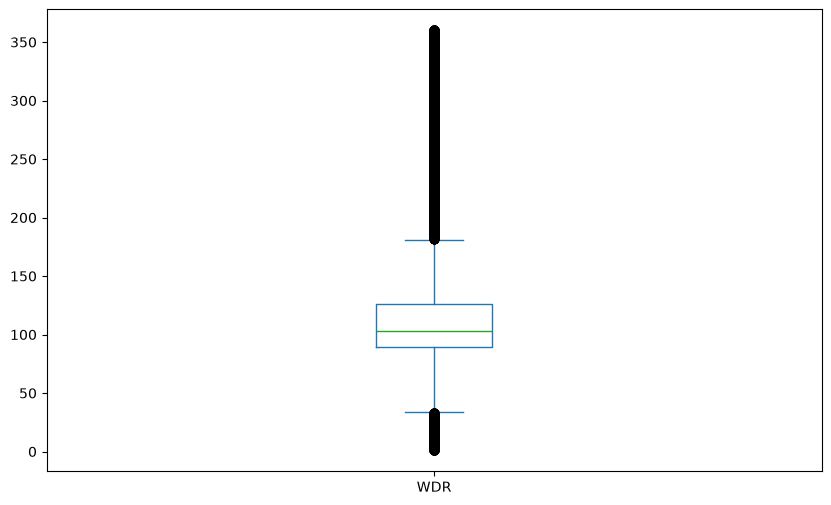

In [16]:
for col in columnas_numericas:
    plt.figure(figsize=(10,6))
    NO2[col].plot(kind='box')
    plt.show()

Parece que hay datos completamente erróneos que se deben de eliminar basándonos en los valores posibles proporcionados por SIMA. 

In [ ]:
"""
Valores posibles de las variables:
PM10: 0-999
PM2.5: 0-999
O3: 0-185
NO: 0-500
NO2: 0-200
SO2: 0-405
C0: 0-20
RH: 0-100
WSR: 0-75
TEMP: -6.5-45.5
SR: 0-1.26
WDR: 0-360
RAINF: 0-80
"""


In [17]:
# Rangos validos segun SIMA. Los valores fuera de estos limites se reemplazan por NaN.
rangos_validos = {
    'PM10': (0, 999),
    'PM2.5': (0, 999),
    'O3': (0, 185),
    'NO': (0, 500),
    'NO2': (0, 200),
    'SO2': (0, 405),
    'CO': (0, 20),
    'RH': (0, 100),
    'WSR': (0, 75),
    'TOUT': (-6.5, 45.5),
    'SR': (0, 1.26),
    'WDR': (0, 360),
    'RAINF': (0, 80)
}

for nombre, estacion in zip(['NO2', 'NO3', 'SO', 'NE3', 'SE3'], estaciones):
    valores_eliminados = 0

    for columna, (minimo, maximo) in rangos_validos.items():
        if columna in estacion.columns:
            valores = pd.to_numeric(estacion[columna], errors='coerce')
            fuera_de_rango = (valores < minimo) | (valores > maximo)
            valores_eliminados += fuera_de_rango.sum()
            estacion.loc[fuera_de_rango, columna] = pd.NA

    print(f'{nombre}: {valores_eliminados} valores fuera de rango reemplazados por NaN')

NO2: 14 valores fuera de rango reemplazados por NaN
NO3: 160 valores fuera de rango reemplazados por NaN
SO: 228 valores fuera de rango reemplazados por NaN
NE3: 44 valores fuera de rango reemplazados por NaN
SE3: 6 valores fuera de rango reemplazados por NaN
